In [1]:
# Import dependencies

import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Set configuration
RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/umerrtx/machine-failure-prediction-using-sensor-data/data.csv"
TARGET = "fail"

TEST_SIZE = 0.15
VALID_SIZE_OF_REMAINDER = 0.17647058823529413

INSPECT_COST = 10.0
MISSED_FAILURE_COST = 500.0
CAPACITY_STEP = 5

QUEUE_EXPORT_PATH = "locked_test_queue.csv"
SUMMARY_EXPORT_PATH = "locked_test_summary.csv"
CANDIDATE_EXPORT_PATH = "candidate_results.csv"
CONFUSION_EXPORT_PATH = "locked_test_confusion_matrix.csv"
FEATURE_IMPORTANCE_EXPORT_PATH = "winning_model_feature_importance.csv"
THRESHOLD_STABILITY_EXPORT_PATH = "threshold_stability_check.csv"
BASELINE_EXPORT_PATH = "baseline_comparison.csv"

MODEL_NAMES = [
    "logistic_regression",
    "extra_trees",
    "gradient_boosting",
    "xgboost",
]

WEIGHT_STYLES = [
    "none",
    "balanced_x0.75",
    "balanced",
    "balanced_x1.25",
    "balanced_x1.5",
]


# Define result structures
@dataclass(frozen=True)
class CandidateSpec:
    model_name: str
    weight_style: str


@dataclass
class ThresholdResult:
    threshold: float
    selected_count: int
    false_positives: int
    false_negatives: int
    total_cost: float
    precision: float
    recall: float


@dataclass
class CapacityResult:
    capacity: int
    inspected_today: int
    urgent_pool: int
    base_inspect_cost: float
    backlog_missed_failure_cost: float
    total_ops_cost: float
    today_precision: float
    urgent_pool_recall: float


# Handle probabilities
def clip_probs(p: np.ndarray) -> np.ndarray:
    return np.clip(np.asarray(p, dtype=float), 1e-6, 1.0 - 1e-6)


# Load data and split it
def load_dataset(path: str, target: str) -> Tuple[pd.DataFrame, pd.Series]:
    data = pd.read_csv(path).drop_duplicates().reset_index(drop=True)
    if target not in data.columns:
        raise ValueError(f"Missing target column: {target}")

    feature_cols = [
        c for c in data.columns
        if c != target and pd.api.types.is_numeric_dtype(data[c])
    ]
    if not feature_cols:
        raise ValueError("No numeric feature columns found.")

    X = data[feature_cols].copy()
    y = data[target].astype(int).copy()
    return X, y


def split_dataset(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float,
    valid_size_of_remainder: float,
    random_state: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_temp,
        y_temp,
        test_size=valid_size_of_remainder,
        stratify=y_temp,
        random_state=random_state,
    )
    return X_train, X_valid, X_test, y_train, y_valid, y_test


# Set class weights
def make_class_weight(style: str, y_train: pd.Series) -> Optional[Dict[int, float]]:
    if style == "none":
        return None

    positives = int(y_train.sum())
    negatives = len(y_train) - positives
    pos_weight = negatives / max(positives, 1)

    multiplier = {
        "balanced_x0.75": 0.75,
        "balanced": 1.0,
        "balanced_x1.25": 1.25,
        "balanced_x1.5": 1.5,
    }[style]
    return {0: 1.0, 1: float(multiplier * pos_weight)}


# Build models
def build_estimator(model_name: str, class_weight: Optional[Dict[int, float]]) -> Pipeline:
    if model_name == "logistic_regression":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            )),
        ])

    if model_name == "extra_trees":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=280,
                min_samples_leaf=2,
                n_jobs=-1,
                class_weight=class_weight,
                random_state=RANDOM_STATE,
            )),
        ])

    if model_name == "gradient_boosting":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_iter=250,
                learning_rate=0.05,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                random_state=RANDOM_STATE,
            )),
        ])

    if model_name == "xgboost":
        if not HAS_XGBOOST:
            raise ImportError("xgboost is not installed")
        scale_pos_weight = 1.0 if class_weight is None else float(class_weight[1] / class_weight[0])
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight,
            )),
        ])

    raise ValueError(f"Unknown model: {model_name}")


# Fit calibrated models
def fit_calibrated_estimator(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    model_name: str,
    weight_style: str,
) -> CalibratedClassifierCV:
    class_weight = make_class_weight(weight_style, y_train)
    base_estimator = build_estimator(model_name, class_weight)
    calibrated = CalibratedClassifierCV(
        estimator=base_estimator,
        method="sigmoid",
        cv=3,
    )
    calibrated.fit(X_train, y_train)
    return calibrated


# Select thresholds
def threshold_cost_curve(
    y_true: pd.Series,
    probabilities: np.ndarray,
    inspect_cost: float,
    missed_failure_cost: float,
) -> pd.DataFrame:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)

    order = np.argsort(-p)
    y_sorted = y[order]
    p_sorted = p[order]

    total_failures = int(y_sorted.sum())
    cumulative_tp = np.cumsum(y_sorted)
    selected_count = np.arange(1, len(y_sorted) + 1)
    false_positives = selected_count - cumulative_tp
    false_negatives = total_failures - cumulative_tp

    total_cost = (false_positives * inspect_cost) + (false_negatives * missed_failure_cost)
    precision = cumulative_tp / selected_count
    recall = cumulative_tp / max(total_failures, 1)

    curve = pd.DataFrame({
        "threshold": p_sorted,
        "selected_count": selected_count,
        "false_positives": false_positives,
        "false_negatives": false_negatives,
        "total_cost": total_cost.astype(float),
        "precision": precision.astype(float),
        "recall": recall.astype(float),
    })

    baseline = pd.DataFrame([{
        "threshold": 1.0,
        "selected_count": 0,
        "false_positives": 0,
        "false_negatives": total_failures,
        "total_cost": float(total_failures * missed_failure_cost),
        "precision": 0.0,
        "recall": 0.0,
    }])

    curve = pd.concat([baseline, curve], ignore_index=True)
    curve = curve.sort_values(["total_cost", "false_negatives", "false_positives"], ascending=[True, True, True])
    return curve.reset_index(drop=True)


def pick_best_threshold(
    y_true: pd.Series,
    probabilities: np.ndarray,
    inspect_cost: float,
    missed_failure_cost: float,
) -> ThresholdResult:
    best = threshold_cost_curve(y_true, probabilities, inspect_cost, missed_failure_cost).iloc[0]
    return ThresholdResult(
        threshold=float(best["threshold"]),
        selected_count=int(best["selected_count"]),
        false_positives=int(best["false_positives"]),
        false_negatives=int(best["false_negatives"]),
        total_cost=float(best["total_cost"]),
        precision=float(best["precision"]),
        recall=float(best["recall"]),
    )


# Apply capacity
def make_capacity_grid(urgent_pool: int, step: int) -> List[int]:
    urgent_pool = max(int(urgent_pool), 0)
    if urgent_pool == 0:
        return [0]
    points = [1]
    points.extend(range(step, urgent_pool + 1, step))
    if urgent_pool not in points:
        points.append(urgent_pool)
    return sorted(set(points))


def build_urgent_queue(y: pd.Series, probabilities: np.ndarray, threshold: float) -> pd.DataFrame:
    queue = pd.DataFrame({
        "actual_fail": np.asarray(y, dtype=int),
        "predicted_failure_probability": clip_probs(probabilities),
    })
    queue["is_urgent"] = queue["predicted_failure_probability"] >= float(threshold)
    queue = queue[queue["is_urgent"]].copy()
    queue = queue.sort_values("predicted_failure_probability", ascending=False).reset_index(drop=True)
    queue["queue_rank"] = np.arange(1, len(queue) + 1)
    return queue


def evaluate_capacity_plan(
    urgent_queue: pd.DataFrame,
    capacity: int,
    inspect_cost: float,
    missed_failure_cost: float,
) -> CapacityResult:
    urgent_pool = len(urgent_queue)
    capacity = min(max(int(capacity), 0), urgent_pool)

    inspected = urgent_queue.iloc[:capacity]
    backlog = urgent_queue.iloc[capacity:]

    base_inspect_cost = float(capacity * inspect_cost)
    backlog_missed_failure_cost = float(backlog["actual_fail"].sum() * missed_failure_cost)
    total_ops_cost = base_inspect_cost + backlog_missed_failure_cost

    urgent_failures = max(int(urgent_queue["actual_fail"].sum()), 1)
    inspected_failures = int(inspected["actual_fail"].sum())
    today_precision = float(inspected_failures / max(capacity, 1)) if capacity > 0 else 0.0
    urgent_pool_recall = float(inspected_failures / urgent_failures)

    return CapacityResult(
        capacity=capacity,
        inspected_today=capacity,
        urgent_pool=urgent_pool,
        base_inspect_cost=base_inspect_cost,
        backlog_missed_failure_cost=backlog_missed_failure_cost,
        total_ops_cost=total_ops_cost,
        today_precision=today_precision,
        urgent_pool_recall=urgent_pool_recall,
    )


def capacity_sweep(
    urgent_queue: pd.DataFrame,
    inspect_cost: float,
    missed_failure_cost: float,
    capacity_step: int,
) -> pd.DataFrame:
    rows = []
    for capacity in make_capacity_grid(len(urgent_queue), capacity_step):
        rows.append(evaluate_capacity_plan(
            urgent_queue=urgent_queue,
            capacity=capacity,
            inspect_cost=inspect_cost,
            missed_failure_cost=missed_failure_cost,
        ).__dict__)
    return pd.DataFrame(rows)


# Score each candidate
def evaluate_candidate(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
    spec: CandidateSpec,
) -> Dict[str, object]:
    row: Dict[str, object] = {
        "model_name": spec.model_name,
        "weight_style": spec.weight_style,
        "fit_error": "",
    }

    try:
        model = fit_calibrated_estimator(X_train, y_train, spec.model_name, spec.weight_style)
        valid_prob = clip_probs(model.predict_proba(X_valid)[:, 1])

        threshold_result = pick_best_threshold(y_valid, valid_prob, INSPECT_COST, MISSED_FAILURE_COST)
        urgent_queue = build_urgent_queue(y_valid, valid_prob, threshold_result.threshold)
        capacity_table = capacity_sweep(
            urgent_queue=urgent_queue,
            inspect_cost=INSPECT_COST,
            missed_failure_cost=MISSED_FAILURE_COST,
            capacity_step=CAPACITY_STEP,
        )

        best_capacity_row = capacity_table.sort_values(
            ["total_ops_cost", "backlog_missed_failure_cost", "today_precision"],
            ascending=[True, True, False],
        ).iloc[0]

        row.update({
            "validation_best_threshold": threshold_result.threshold,
            "validation_total_cost": threshold_result.total_cost,
            "validation_selected_count": threshold_result.selected_count,
            "validation_false_positives": threshold_result.false_positives,
            "validation_false_negatives": threshold_result.false_negatives,
            "validation_precision": threshold_result.precision,
            "validation_recall": threshold_result.recall,
            "validation_roc_auc": float(roc_auc_score(y_valid, valid_prob)),
            "validation_pr_auc": float(average_precision_score(y_valid, valid_prob)),
            "validation_brier": float(brier_score_loss(y_valid, valid_prob)),
            "valid_urgent_pool": int(len(urgent_queue)),
            "best_capacity": int(best_capacity_row["capacity"]),
            "best_capacity_total_ops_cost": float(best_capacity_row["total_ops_cost"]),
            "best_capacity_backlog_missed_failure_cost": float(best_capacity_row["backlog_missed_failure_cost"]),
            "best_capacity_precision": float(best_capacity_row["today_precision"]),
            "best_capacity_urgent_pool_recall": float(best_capacity_row["urgent_pool_recall"]),
        })
    except Exception as exc:
        row.update({
            "validation_best_threshold": np.nan,
            "validation_total_cost": np.nan,
            "validation_selected_count": np.nan,
            "validation_false_positives": np.nan,
            "validation_false_negatives": np.nan,
            "validation_precision": np.nan,
            "validation_recall": np.nan,
            "validation_roc_auc": np.nan,
            "validation_pr_auc": np.nan,
            "validation_brier": np.nan,
            "valid_urgent_pool": np.nan,
            "best_capacity": np.nan,
            "best_capacity_total_ops_cost": np.nan,
            "best_capacity_backlog_missed_failure_cost": np.nan,
            "best_capacity_precision": np.nan,
            "best_capacity_urgent_pool_recall": np.nan,
            "fit_error": f"{type(exc).__name__}: {exc}",
        })

    return row


# Build candidate results
def build_candidate_table(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
) -> pd.DataFrame:
    rows: List[Dict[str, object]] = []
    for model_name in MODEL_NAMES:
        for weight_style in WEIGHT_STYLES:
            rows.append(evaluate_candidate(
                X_train=X_train,
                y_train=y_train,
                X_valid=X_valid,
                y_valid=y_valid,
                spec=CandidateSpec(model_name=model_name, weight_style=weight_style),
            ))
    return pd.DataFrame(rows)


# Build test output
def build_test_output(
    X_test: pd.DataFrame,
    y_test: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    selected_model: str,
    selected_weight: str,
    deployment_rule: str,
) -> pd.DataFrame:
    output = X_test.copy().reset_index(drop=True)
    output.insert(0, "machine_id", np.arange(1, len(output) + 1))
    output["actual_fail"] = y_test.reset_index(drop=True).astype(int)
    output["predicted_failure_probability"] = clip_probs(probabilities)
    output["selected_model"] = selected_model
    output["selected_weight"] = selected_weight
    output["deployment_rule"] = deployment_rule
    output["selected_threshold"] = float(threshold)
    output["is_urgent"] = output["predicted_failure_probability"] >= float(threshold)
    output = output.sort_values("predicted_failure_probability", ascending=False).reset_index(drop=True)
    output["queue_rank"] = np.arange(1, len(output) + 1)
    output["action"] = "monitor"

    inspect_mask = output["is_urgent"] & (output["queue_rank"] <= int(locked_capacity))
    backlog_mask = output["is_urgent"] & (output["queue_rank"] > int(locked_capacity))
    output.loc[inspect_mask, "action"] = "inspect_now"
    output.loc[backlog_mask, "action"] = "backlog_urgent"
    return output


# Extra locked-policy diagnostics
def fixed_threshold_metrics(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    inspect_cost: float,
    missed_failure_cost: float,
) -> Dict[str, object]:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    predicted_urgent = p >= float(threshold)

    tp = int(((predicted_urgent == 1) & (y == 1)).sum())
    fp = int(((predicted_urgent == 1) & (y == 0)).sum())
    tn = int(((predicted_urgent == 0) & (y == 0)).sum())
    fn = int(((predicted_urgent == 0) & (y == 1)).sum())

    selected_count = int(predicted_urgent.sum())
    total_failures = int(y.sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(total_failures, 1)
    specificity = tn / max(tn + fp, 1)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    total_cost = float(fp * inspect_cost + fn * missed_failure_cost)

    return {
        "threshold": float(threshold),
        "selected_count": selected_count,
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn,
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1_score": float(f1),
        "total_cost": total_cost,
    }


def build_confusion_matrix_table(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    inspect_cost: float,
    missed_failure_cost: float,
) -> pd.DataFrame:
    metrics = fixed_threshold_metrics(
        y_true=y_true,
        probabilities=probabilities,
        threshold=threshold,
        inspect_cost=inspect_cost,
        missed_failure_cost=missed_failure_cost,
    )

    return pd.DataFrame([
        {
            "threshold": metrics["threshold"],
            "actual_class": "no_fail",
            "predicted_class": "monitor",
            "rows": metrics["true_negatives"],
        },
        {
            "threshold": metrics["threshold"],
            "actual_class": "no_fail",
            "predicted_class": "urgent",
            "rows": metrics["false_positives"],
        },
        {
            "threshold": metrics["threshold"],
            "actual_class": "fail",
            "predicted_class": "monitor",
            "rows": metrics["false_negatives"],
        },
        {
            "threshold": metrics["threshold"],
            "actual_class": "fail",
            "predicted_class": "urgent",
            "rows": metrics["true_positives"],
        },
    ])


def extract_model_feature_importance(
    fitted_pipeline: Pipeline,
    X_reference: pd.DataFrame,
    y_reference: pd.Series,
    feature_names: List[str],
) -> pd.DataFrame:
    model = fitted_pipeline.named_steps["model"]

    if hasattr(model, "feature_importances_"):
        raw_importance = np.asarray(model.feature_importances_, dtype=float)
        out = pd.DataFrame({
            "feature": feature_names,
            "importance": raw_importance,
            "importance_type": "model_feature_importance",
        })

    elif hasattr(model, "coef_"):
        coef = np.asarray(model.coef_).reshape(-1)
        out = pd.DataFrame({
            "feature": feature_names,
            "importance": np.abs(coef),
            "signed_coefficient": coef,
            "importance_type": "absolute_logistic_coefficient",
        })

    else:
        sample_n = min(len(X_reference), 600)
        X_sample = X_reference.sample(n=sample_n, random_state=RANDOM_STATE) if len(X_reference) > sample_n else X_reference
        y_sample = y_reference.loc[X_sample.index]

        perm = permutation_importance(
            fitted_pipeline,
            X_sample,
            y_sample,
            scoring="average_precision",
            n_repeats=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        out = pd.DataFrame({
            "feature": feature_names,
            "importance": perm.importances_mean,
            "importance_std": perm.importances_std,
            "importance_type": "permutation_pr_auc_drop",
        })

    out["importance"] = out["importance"].fillna(0.0).astype(float)
    total = float(out["importance"].abs().sum())
    out["importance_share"] = 0.0 if total == 0 else out["importance"].abs() / total
    return out.sort_values(["importance", "feature"], ascending=[False, True]).reset_index(drop=True)


def threshold_stability_check(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    inspect_cost: float,
    missed_failure_cost: float,
) -> pd.DataFrame:
    multipliers = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
    rows = []

    for multiplier in multipliers:
        candidate_threshold = float(np.clip(threshold * multiplier, 1e-6, 1.0 - 1e-6))
        threshold_metrics = fixed_threshold_metrics(
            y_true=y_true,
            probabilities=probabilities,
            threshold=candidate_threshold,
            inspect_cost=inspect_cost,
            missed_failure_cost=missed_failure_cost,
        )
        urgent_queue = build_urgent_queue(y_true, probabilities, candidate_threshold)
        capacity_metrics = evaluate_capacity_plan(
            urgent_queue=urgent_queue,
            capacity=locked_capacity,
            inspect_cost=inspect_cost,
            missed_failure_cost=missed_failure_cost,
        )

        rows.append({
            "threshold_multiplier": float(multiplier),
            "threshold": candidate_threshold,
            "selected_count": int(threshold_metrics["selected_count"]),
            "threshold_total_cost": float(threshold_metrics["total_cost"]),
            "threshold_precision": float(threshold_metrics["precision"]),
            "threshold_recall": float(threshold_metrics["recall"]),
            "false_positives": int(threshold_metrics["false_positives"]),
            "false_negatives": int(threshold_metrics["false_negatives"]),
            "locked_capacity": int(locked_capacity),
            "capacity_inspected_today": int(capacity_metrics.inspected_today),
            "capacity_urgent_pool": int(capacity_metrics.urgent_pool),
            "capacity_total_ops_cost": float(capacity_metrics.total_ops_cost),
            "capacity_backlog_missed_failure_cost": float(capacity_metrics.backlog_missed_failure_cost),
            "capacity_today_precision": float(capacity_metrics.today_precision),
            "capacity_urgent_pool_recall": float(capacity_metrics.urgent_pool_recall),
        })

    return pd.DataFrame(rows)


def build_baseline_comparison(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
    locked_capacity: int,
    inspect_cost: float,
    missed_failure_cost: float,
) -> pd.DataFrame:
    y = np.asarray(y_true, dtype=int)
    p = clip_probs(probabilities)
    total_rows = len(y)
    total_failures = int(y.sum())

    urgent_queue = build_urgent_queue(y_true, p, threshold)
    locked_capacity_eval = evaluate_capacity_plan(
        urgent_queue=urgent_queue,
        capacity=locked_capacity,
        inspect_cost=inspect_cost,
        missed_failure_cost=missed_failure_cost,
    )
    locked_threshold_metrics = fixed_threshold_metrics(
        y_true=y_true,
        probabilities=p,
        threshold=threshold,
        inspect_cost=inspect_cost,
        missed_failure_cost=missed_failure_cost,
    )

    none_cost = float(total_failures * missed_failure_cost)
    all_cost = float(total_rows * inspect_cost)

    random_rows = []
    rng = np.random.default_rng(RANDOM_STATE)
    capacity = min(int(locked_capacity), total_rows)
    for _ in range(300):
        chosen = rng.choice(total_rows, size=capacity, replace=False) if capacity > 0 else np.array([], dtype=int)
        inspected_failures = int(y[chosen].sum()) if capacity > 0 else 0
        missed_failures = total_failures - inspected_failures
        random_rows.append({
            "total_ops_cost": float(capacity * inspect_cost + missed_failures * missed_failure_cost),
            "today_precision": float(inspected_failures / max(capacity, 1)) if capacity > 0 else 0.0,
            "recall": float(inspected_failures / max(total_failures, 1)),
        })
    random_df = pd.DataFrame(random_rows)

    return pd.DataFrame([
        {
            "baseline": "locked_model_threshold_and_capacity",
            "description": "Use the selected model, selected threshold, and locked daily capacity.",
            "inspected_today": int(locked_capacity_eval.inspected_today),
            "urgent_pool": int(locked_capacity_eval.urgent_pool),
            "total_ops_cost": float(locked_capacity_eval.total_ops_cost),
            "today_precision": float(locked_capacity_eval.today_precision),
            "recall": float(locked_capacity_eval.urgent_pool_recall),
            "threshold_total_cost_before_capacity": float(locked_threshold_metrics["total_cost"]),
        },
        {
            "baseline": "inspect_none",
            "description": "Inspect no rows and miss every failure.",
            "inspected_today": 0,
            "urgent_pool": 0,
            "total_ops_cost": none_cost,
            "today_precision": 0.0,
            "recall": 0.0,
            "threshold_total_cost_before_capacity": none_cost,
        },
        {
            "baseline": "inspect_all",
            "description": "Inspect every test row.",
            "inspected_today": int(total_rows),
            "urgent_pool": int(total_rows),
            "total_ops_cost": all_cost,
            "today_precision": float(total_failures / max(total_rows, 1)),
            "recall": 1.0,
            "threshold_total_cost_before_capacity": all_cost,
        },
        {
            "baseline": "random_capacity_mean",
            "description": "Randomly inspect the same number of rows as the locked daily capacity.",
            "inspected_today": int(capacity),
            "urgent_pool": int(capacity),
            "total_ops_cost": float(random_df["total_ops_cost"].mean()),
            "today_precision": float(random_df["today_precision"].mean()),
            "recall": float(random_df["recall"].mean()),
            "threshold_total_cost_before_capacity": np.nan,
        },
    ])


# Run pipeline
def main() -> None:
    X, y = load_dataset(DATA_PATH, TARGET)
    X_train, X_valid, X_test, y_train, y_valid, y_test = split_dataset(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        valid_size_of_remainder=VALID_SIZE_OF_REMAINDER,
        random_state=RANDOM_STATE,
    )

    candidate_table = build_candidate_table(X_train, y_train, X_valid, y_valid)
    usable = candidate_table[candidate_table["fit_error"] == ""].copy().reset_index(drop=True)
    if usable.empty:
        raise ValueError("All candidate fits failed.")

    # Stage 1 is now true ML ranking quality, not probability calibration first.
    # PR AUC comes first because this is a rare event ranking problem.
    # ROC AUC comes second for overall class separation.
    # Brier stays as a tie breaker for probability quality.
    ml_only_table = usable.sort_values(
        ["validation_pr_auc", "validation_roc_auc", "validation_brier"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    threshold_first_table = usable.sort_values(
        ["validation_total_cost", "validation_false_negatives", "validation_brier", "validation_pr_auc"],
        ascending=[True, True, True, False],
    ).reset_index(drop=True)

    capacity_constrained_table = usable.sort_values(
        ["best_capacity_total_ops_cost", "best_capacity_backlog_missed_failure_cost", "best_capacity_precision", "validation_total_cost"],
        ascending=[True, True, False, True],
    ).reset_index(drop=True)

    ml_only_best = ml_only_table.iloc[0]
    threshold_first_best = threshold_first_table.iloc[0]
    capacity_constrained_best = capacity_constrained_table.iloc[0]

    deployment_model_name = str(capacity_constrained_best["model_name"])
    deployment_weight_style = str(capacity_constrained_best["weight_style"])
    deployment_threshold = float(capacity_constrained_best["validation_best_threshold"])
    deployment_capacity = int(capacity_constrained_best["best_capacity"])

    X_train_final = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
    y_train_final = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)
    deployment_model = fit_calibrated_estimator(
        X_train_final,
        y_train_final,
        deployment_model_name,
        deployment_weight_style,
    )

    test_prob = clip_probs(deployment_model.predict_proba(X_test)[:, 1])
    test_capacity_eval = evaluate_capacity_plan(
        urgent_queue=build_urgent_queue(y_test, test_prob, deployment_threshold),
        capacity=deployment_capacity,
        inspect_cost=INSPECT_COST,
        missed_failure_cost=MISSED_FAILURE_COST,
    )

    queue_output = build_test_output(
        X_test=X_test,
        y_test=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        locked_capacity=deployment_capacity,
        selected_model=deployment_model_name,
        selected_weight=deployment_weight_style,
        deployment_rule="capacity_constrained_validation_cost",
    )

    test_confusion_table = build_confusion_matrix_table(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        inspect_cost=INSPECT_COST,
        missed_failure_cost=MISSED_FAILURE_COST,
    )

    feature_importance_model = build_estimator(
        deployment_model_name,
        make_class_weight(deployment_weight_style, y_train_final),
    )
    feature_importance_model.fit(X_train_final, y_train_final)
    feature_importance_table = extract_model_feature_importance(
        fitted_pipeline=feature_importance_model,
        X_reference=X_train_final,
        y_reference=y_train_final,
        feature_names=list(X_train_final.columns),
    )

    valid_selected_model = fit_calibrated_estimator(
        X_train,
        y_train,
        deployment_model_name,
        deployment_weight_style,
    )
    valid_selected_prob = clip_probs(valid_selected_model.predict_proba(X_valid)[:, 1])

    threshold_stability_table = threshold_stability_check(
        y_true=y_valid,
        probabilities=valid_selected_prob,
        threshold=deployment_threshold,
        locked_capacity=deployment_capacity,
        inspect_cost=INSPECT_COST,
        missed_failure_cost=MISSED_FAILURE_COST,
    )

    baseline_table = build_baseline_comparison(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        locked_capacity=deployment_capacity,
        inspect_cost=INSPECT_COST,
        missed_failure_cost=MISSED_FAILURE_COST,
    )

    test_fixed_threshold_metrics = fixed_threshold_metrics(
        y_true=y_test,
        probabilities=test_prob,
        threshold=deployment_threshold,
        inspect_cost=INSPECT_COST,
        missed_failure_cost=MISSED_FAILURE_COST,
    )

    summary_output = pd.DataFrame([{
        "primary_rule": "capacity_constrained_validation_cost",
        "secondary_rule": "threshold_cost_before_capacity",
        "ml_only_rule": "best_ml_ranking_on_validation",
        "inspect_cost": INSPECT_COST,
        "missed_failure_cost": MISSED_FAILURE_COST,
        "threshold_first_model": str(threshold_first_best["model_name"]),
        "threshold_first_weight": str(threshold_first_best["weight_style"]),
        "threshold_first_threshold": float(threshold_first_best["validation_best_threshold"]),
        "threshold_first_validation_total_cost": float(threshold_first_best["validation_total_cost"]),
        "threshold_first_best_capacity": int(threshold_first_best["best_capacity"]),
        "threshold_first_best_capacity_total_ops_cost": float(threshold_first_best["best_capacity_total_ops_cost"]),
        "capacity_constrained_model": deployment_model_name,
        "capacity_constrained_weight": deployment_weight_style,
        "capacity_constrained_threshold": deployment_threshold,
        "capacity_constrained_validation_total_cost": float(capacity_constrained_best["validation_total_cost"]),
        "capacity_constrained_best_capacity": deployment_capacity,
        "capacity_constrained_best_capacity_total_ops_cost": float(capacity_constrained_best["best_capacity_total_ops_cost"]),
        "ml_only_best_model": str(ml_only_best["model_name"]),
        "ml_only_best_weight": str(ml_only_best["weight_style"]),
        "ml_only_best_validation_pr_auc": float(ml_only_best["validation_pr_auc"]),
        "ml_only_best_validation_roc_auc": float(ml_only_best["validation_roc_auc"]),
        "ml_only_best_validation_brier": float(ml_only_best["validation_brier"]),
        "test_roc_auc": float(roc_auc_score(y_test, test_prob)),
        "test_pr_auc": float(average_precision_score(y_test, test_prob)),
        "test_brier": float(brier_score_loss(y_test, test_prob)),
        "test_urgent_pool": int(test_capacity_eval.urgent_pool),
        "test_inspected_today": int(test_capacity_eval.inspected_today),
        "test_base_inspect_cost": float(test_capacity_eval.base_inspect_cost),
        "test_backlog_missed_failure_cost": float(test_capacity_eval.backlog_missed_failure_cost),
        "test_total_ops_cost": float(test_capacity_eval.total_ops_cost),
        "test_today_precision": float(test_capacity_eval.today_precision),
        "test_urgent_pool_recall": float(test_capacity_eval.urgent_pool_recall),
        "test_threshold_true_positives": int(test_fixed_threshold_metrics["true_positives"]),
        "test_threshold_false_positives": int(test_fixed_threshold_metrics["false_positives"]),
        "test_threshold_true_negatives": int(test_fixed_threshold_metrics["true_negatives"]),
        "test_threshold_false_negatives": int(test_fixed_threshold_metrics["false_negatives"]),
        "test_threshold_precision": float(test_fixed_threshold_metrics["precision"]),
        "test_threshold_recall": float(test_fixed_threshold_metrics["recall"]),
        "test_threshold_f1_score": float(test_fixed_threshold_metrics["f1_score"]),
        "test_threshold_total_cost_before_capacity": float(test_fixed_threshold_metrics["total_cost"]),
        "best_feature": str(feature_importance_table.iloc[0]["feature"]) if len(feature_importance_table) else "",
        "best_feature_importance": float(feature_importance_table.iloc[0]["importance"]) if len(feature_importance_table) else np.nan,
        "best_baseline_total_ops_cost": float(baseline_table["total_ops_cost"].min()),
    }])

    candidate_table.to_csv(CANDIDATE_EXPORT_PATH, index=False)
    queue_output.to_csv(QUEUE_EXPORT_PATH, index=False)
    summary_output.to_csv(SUMMARY_EXPORT_PATH, index=False)
    test_confusion_table.to_csv(CONFUSION_EXPORT_PATH, index=False)
    feature_importance_table.to_csv(FEATURE_IMPORTANCE_EXPORT_PATH, index=False)
    threshold_stability_table.to_csv(THRESHOLD_STABILITY_EXPORT_PATH, index=False)
    baseline_table.to_csv(BASELINE_EXPORT_PATH, index=False)


if __name__ == "__main__":
    main()

# Machine Risk Triage: How ML turns into operations value

Machines can give warning signs before they fail. Here, each row is one machine observation. The sensor numbers in that row are the measurements for that machine, and I treat rows as separate observations. This notebook uses those sensor values to build one urgent queue.

Cell 1 does the calculation. This report cell only calls the saved outputs: the final selected policy, locked test performance, confusion matrix, feature importance, threshold stability, baseline comparison, and final interpretation. That keeps the report aligned to the pipeline and avoids reselecting anything inside the report.

## Project setup, assumptions, and references

This section explains the main notebook choices.

Key setup
- Each row is one machine observation.
- Sensor values in that row are the measurements for that row.
- Rows are treated as independent observations.
- The workflow is split into train, validation, and test. Validation compares candidates, chooses the score cutoff, and chooses the daily inspection limit. Test stays untouched until the final rule is locked.

Cost assumptions
- Inspect cost is set to USD 10 per inspected row.
- Missed failure cost is set to USD 500 for a failed row left out of inspection.
- These values are proxy costs that fit this triage setup: false alarms are relatively cheap, but missed failures are costly.
- Caveat: these are benchmark costs, not plant accounting costs. Deployment should replace them with local labor, downtime, parts, and production loss values.

Pipeline order
- Cell 1 ranks ML candidates on validation.
- Cell 1 compares threshold cost on validation.
- Cell 1 adds the daily capacity rule and locks the final policy.
- Cell 1 refits on train plus validation and evaluates once on test.
- This cell reports those saved results only.

Reference dataset
- APS Failure at Scania Trucks: https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks

,Item,Choice used in notebook
0,Rows,Independent machine observations
1,Target,fail
2,Train / validation / test split,About 70 / 15 / 15
3,Inspect cost,$10
4,Missed failure cost,$500
5,Candidate grid,4 models x 5 weight styles = 20 candidates
6,Report rule,Read saved Cell 1 outputs only


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 1. This table lists the split, cost values, candidate grid, and report rule.</em></div>

## Pipeline winner path

The winner can change as the problem becomes more realistic. The ML-only winner is about ranking quality. The threshold winner is about inspection economics. The final deployed policy is the capacity constrained winner.

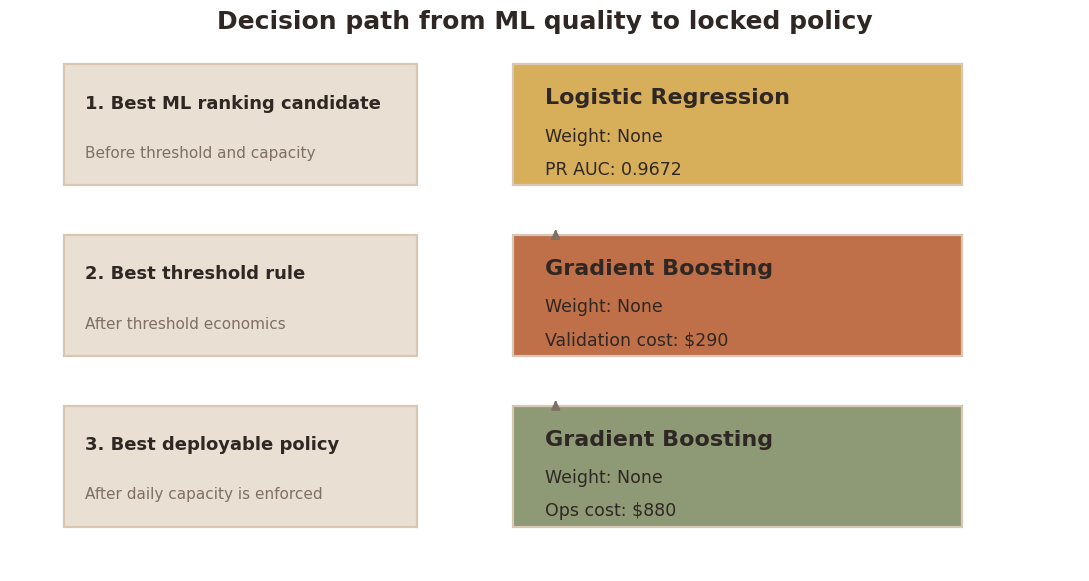

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 1. This figure reads the saved winners from Cell 1. No stage is recomputed in the report cell.</em></div>

## Final selected policy

This is the locked deployment rule. Rows above the risk line enter the urgent pool. Then the highest risk rows are inspected until the daily capacity is reached.

,Metric,Value
0,Deployment model,Gradient Boosting
1,Deployment weight,None
2,Locked threshold,0.0632
3,Locked daily capacity,88
4,Validation threshold cost,$290
5,Validation capacity constrained cost,$880


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 2. Final selected policy loaded from locked_test_summary.csv.</em></div>

...

## Locked test performance

,Metric,Value
0,Test ROC AUC,0.9763
1,Test PR AUC,0.9652
2,Test Brier,0.0603
3,Test urgent pool,101
4,Test inspected today,88
5,Test inspection cost,$880
6,Test backlog missed failure cost,$500
7,Test total operations cost,"$1,380"
8,Test today precision,0.6591
9,Test urgent pool recall,0.9831


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 3. Locked test results after all model and rule choices were fixed in Cell 1.</em></div>

,Action,Rows,Share
0,inspect_now,88,61.97%
1,monitor,41,28.87%
2,backlog_urgent,13,9.15%


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 4. Test rows by final action under the locked rule.</em></div>

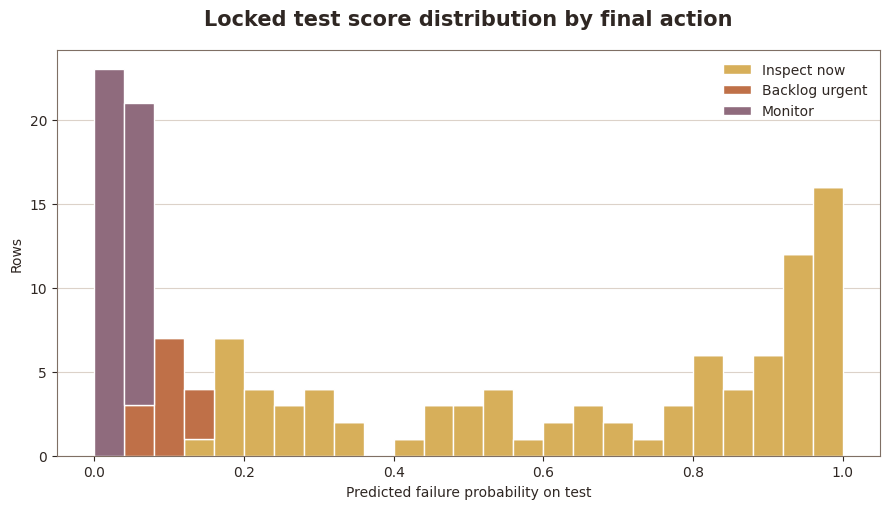

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 2. Final actions from the saved locked test queue. Higher score rows move into urgent actions.</em></div>

## Confusion matrix

This table checks the locked threshold before the daily capacity split. It shows how many failed rows and non failed rows land in urgent versus monitor.

,threshold,actual_class,predicted_class,rows
0,0.063241,no_fail,monitor,41
1,0.063241,no_fail,urgent,42
2,0.063241,fail,monitor,0
3,0.063241,fail,urgent,59


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 5. Confusion matrix at the selected threshold, saved by Cell 1.</em></div>

## Feature importance

These are the strongest signals for the winning model. They are model importance scores, not causal effects.

,feature,importance,importance_std,importance_type,importance_share
0,VOC,0.227784,0.014389,permutation_pr_auc_drop,0.801782
1,USS,0.023828,0.006645,permutation_pr_auc_drop,0.083872
2,CS,0.011136,0.001635,permutation_pr_auc_drop,0.039199
3,AQ,0.010068,0.002387,permutation_pr_auc_drop,0.035439
4,footfall,0.005958,0.001009,permutation_pr_auc_drop,0.020971
5,RP,0.003395,0.000677,permutation_pr_auc_drop,0.011949
6,Temperature,0.001419,0.000393,permutation_pr_auc_drop,0.004995
7,tempMode,0.000496,0.000138,permutation_pr_auc_drop,0.001747
8,IP,0.000013,0.000027,permutation_pr_auc_drop,0.000047


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 6. Top feature importance rows saved by Cell 1.</em></div>

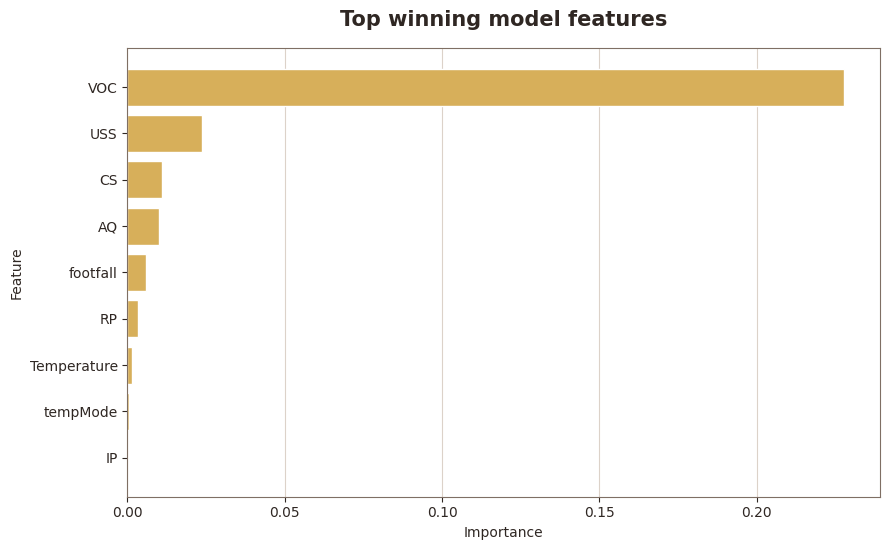

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 3. Highest bars are the strongest model signals for the locked winner.</em></div>

## Threshold stability

This checks whether the selected cutoff is fragile. The best case is a nearby range with similar cost and few missed failures.

,threshold_multiplier,threshold,selected_count,threshold_total_cost,threshold_precision,threshold_recall,false_positives,false_negatives,locked_capacity,capacity_inspected_today,capacity_urgent_pool,capacity_total_ops_cost,capacity_backlog_missed_failure_cost,capacity_today_precision,capacity_urgent_pool_recall
0,0.85,0.0538,95,$360,0.6211,1.0000,36,0,88,88,95,$880,$0,0.6705,1.0000
1,0.90,0.0569,91,$320,0.6484,1.0000,32,0,88,88,91,$880,$0,0.6705,1.0000
2,0.95,0.0601,89,$300,0.6629,1.0000,30,0,88,88,89,$880,$0,0.6705,1.0000
3,1.00,0.0632,88,$290,0.6705,1.0000,29,0,88,88,88,$880,$0,0.6705,1.0000
4,1.05,0.0664,85,$770,0.6824,0.9831,27,1,88,85,85,$850,$0,0.6824,1.0000
5,1.10,0.0696,83,"$1,260",0.6867,0.9661,26,2,88,83,83,$830,$0,0.6867,1.0000
6,1.15,0.0727,79,"$2,240",0.6962,0.9322,24,4,88,79,79,$790,$0,0.6962,1.0000


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 7. Threshold stability check saved by Cell 1.</em></div>

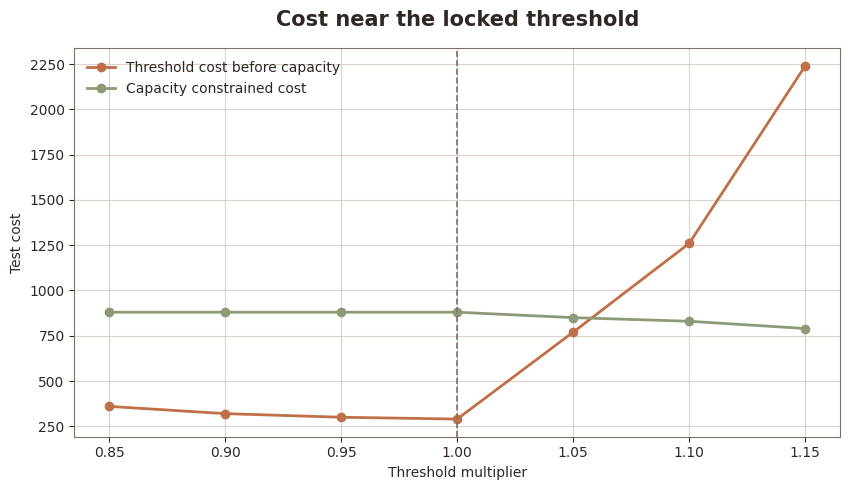

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 4. The dashed line is the selected threshold multiplier of 1.0.</em></div>

## Baseline comparison

The locked policy is compared against simple alternatives, so it is not judged in isolation. Lower total operations cost is better.

,baseline,description,inspected_today,urgent_pool,total_ops_cost,today_precision,recall,threshold_total_cost_before_capacity
0,locked_model_threshold_and_capacity,"Use the selected model, selected threshold, and locked daily capacity.",88,101,"$1,380",0.6591,0.9831,$420
1,inspect_none,Inspect no rows and miss every failure.,0,0,"$29,500",0.0000,0.0000,"$29,500"
2,inspect_all,Inspect every test row.,142,142,"$1,420",0.4155,1.0000,"$1,420"
3,random_capacity_mean,Randomly inspect the same number of rows as the locked daily capacity.,88,88,"$12,023",0.4172,0.6223,$nan


<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Table 8. Baseline comparison saved by Cell 1.</em></div>

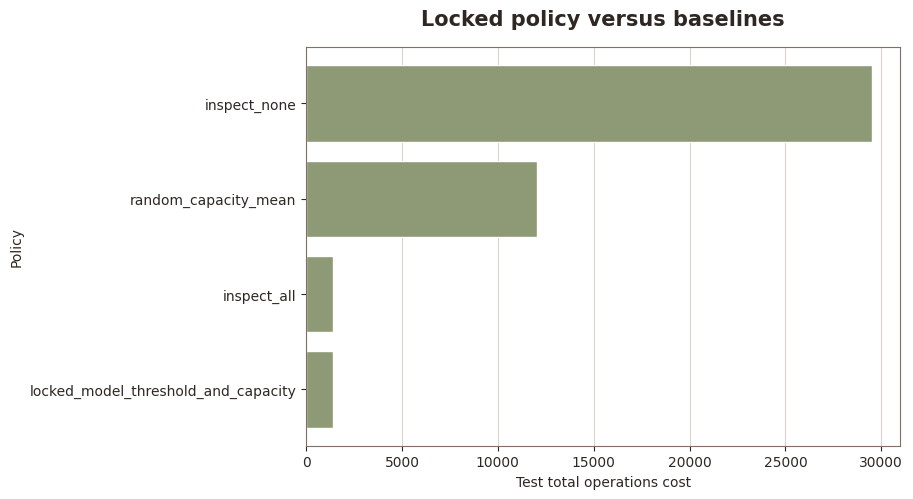

<div style='margin-top:6px; color:#7F6F64; font-size:0.95em;'><em>Figure 5. Lower cost is better. The locked policy is compared with simple operating rules.</em></div>

## Final interpretation

On test, I inspect 88 rows today out of an urgent pool of 101. Test total operations cost is $1,380, today precision is 0.6591, and urgent pool recall is 0.9831.

Bottom line. The final model is useful as a triage queue because it concentrates likely failures into a smaller urgent group, then respects the inspection capacity. The main caveat is that the dollar costs are benchmark proxy values. For deployment, replace them with plant specific costs and rerun Cell 1.

In [2]:
# Report aligned to the pipeline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str

CANDIDATE_PATH = Path('/kaggle/working/candidate_results.csv')
SUMMARY_PATH = Path('/kaggle/working/locked_test_summary.csv')
QUEUE_PATH = Path('/kaggle/working/locked_test_queue.csv')
CONFUSION_PATH = Path('/kaggle/working/locked_test_confusion_matrix.csv')
FEATURE_IMPORTANCE_PATH = Path('/kaggle/working/winning_model_feature_importance.csv')
THRESHOLD_STABILITY_PATH = Path('/kaggle/working/threshold_stability_check.csv')
BASELINE_PATH = Path('/kaggle/working/baseline_comparison.csv')

candidate_df = pd.read_csv(CANDIDATE_PATH)
summary_df = pd.read_csv(SUMMARY_PATH)
queue_df = pd.read_csv(QUEUE_PATH)
confusion_df = pd.read_csv(CONFUSION_PATH)
feature_importance_df = pd.read_csv(FEATURE_IMPORTANCE_PATH)
threshold_stability_df = pd.read_csv(THRESHOLD_STABILITY_PATH)
baseline_df = pd.read_csv(BASELINE_PATH)
summary_row = summary_df.iloc[0]

PALETTE = {
    'sand': '#E9DFD2',
    'sand_dark': '#D7C7B3',
    'gold': '#D7AF5A',
    'rust': '#BF7048',
    'olive': '#8E9A76',
    'plum': '#8F6B7D',
    'ink': '#2F2723',
    'muted': '#7F6F64',
    'grid': '#D9CEC4',
    'inspect': '#D7AF5A',
    'backlog': '#BF7048',
    'monitor': '#8F6B7D',
}

plt.rcParams['axes.edgecolor'] = PALETTE['muted']
plt.rcParams['axes.labelcolor'] = PALETTE['ink']
plt.rcParams['xtick.color'] = PALETTE['ink']
plt.rcParams['ytick.color'] = PALETTE['ink']
plt.rcParams['text.color'] = PALETTE['ink']


def show_md(text):
    display(Markdown(text))


def show_caption(text):
    show_md(
        f"<div style='margin-top:6px; color:{PALETTE['muted']}; font-size:0.95em;'><em>{text}</em></div>"
    )


def fmt_model(name):
    return str(name).replace('_', ' ').title()


def fmt_weight(name):
    name = str(name)
    if name == 'none':
        return 'None'
    return name.replace('_x', ' x ').replace('_', ' ').title()


def fmt_money(value):
    return f"${float(value):,.0f}"


def fmt_count(value):
    return f"{int(float(value)):,}"


def fmt_score(value):
    return f"{float(value):.4f}"


def make_barh_plot(df, value_col, label_col, title, xlabel, color):
    plot_df = df.copy().iloc[::-1]
    fig, ax = plt.subplots(figsize=(10.8, 5.3))
    ax.barh(
        plot_df[label_col],
        plot_df[value_col],
        color=color,
        edgecolor='white',
        linewidth=1.2
    )
    ax.set_title(
        title,
        pad=16,
        fontsize=16,
        fontweight='semibold',
        color=PALETTE['ink']
    )
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', color=PALETTE['grid'], linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    fig.subplots_adjust(top=0.86)
    plt.tight_layout()
    plt.show()


usable = candidate_df[candidate_df['fit_error'].fillna('') == ''].copy().reset_index(drop=True)

report_text = {
    'report_title': 'Machine Risk Triage: How ML turns into operations value',
    'report_intro': (
        'Machines can give warning signs before they fail. '
        'Here, each row is one machine observation. The sensor numbers in that row are the measurements for that machine, '
        'and I treat rows as separate observations. This notebook uses those sensor values to build one urgent queue.\n\n'
        'Cell 1 does the calculation. This report cell only calls the saved outputs: the final selected policy, locked test performance, '
        'confusion matrix, feature importance, threshold stability, baseline comparison, and final interpretation. '
        'That keeps the report aligned to the pipeline and avoids reselecting anything inside the report.'
    ),
    'sections': {
        'assumptions_setup': {
            'title': 'Project setup, assumptions, and references',
            'intro': (
                'This section explains the main notebook choices.\n\n'
                'Key setup\n'
                '- Each row is one machine observation.\n'
                '- Sensor values in that row are the measurements for that row.\n'
                '- Rows are treated as independent observations.\n'
                '- The workflow is split into train, validation, and test. Validation compares candidates, chooses the score cutoff, and chooses the daily inspection limit. Test stays untouched until the final rule is locked.\n\n'
                'Cost assumptions\n'
                '- Inspect cost is set to USD 10 per inspected row.\n'
                '- Missed failure cost is set to USD 500 for a failed row left out of inspection.\n'
                '- These values are proxy costs that fit this triage setup: false alarms are relatively cheap, but missed failures are costly.\n'
                '- Caveat: these are benchmark costs, not plant accounting costs. Deployment should replace them with local labor, downtime, parts, and production loss values.\n\n'
                'Pipeline order\n'
                '- Cell 1 ranks ML candidates on validation.\n'
                '- Cell 1 compares threshold cost on validation.\n'
                '- Cell 1 adds the daily capacity rule and locks the final policy.\n'
                '- Cell 1 refits on train plus validation and evaluates once on test.\n'
                '- This cell reports those saved results only.\n\n'
                'Reference dataset\n'
                '- APS Failure at Scania Trucks: https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks'
            )
        },
        'winner_path': {
            'title': 'Pipeline winner path',
            'intro': (
                'The winner can change as the problem becomes more realistic. '
                'The ML-only winner is about ranking quality. The threshold winner is about inspection economics. '
                'The final deployed policy is the capacity constrained winner.'
            )
        },
        'stage4_test': {
            'title': 'Locked test check of the final deployment rule',
            'intro': (
                'Only after the model family, weight style, threshold, and daily capacity are fixed do I touch test. '
                'The final model is refit on train plus validation, then scored once on the held out test rows. '
                'The tables below are loaded from the saved Cell 1 outputs.'
            )
        }
    }
}

show_md(f"# {report_text['report_title']}")
show_md(report_text['report_intro'])

show_md(f"## {report_text['sections']['assumptions_setup']['title']}")
show_md(report_text['sections']['assumptions_setup']['intro'])

setup_table = pd.DataFrame([
    ['Rows', 'Independent machine observations'],
    ['Target', 'fail'],
    ['Train / validation / test split', 'About 70 / 15 / 15'],
    ['Inspect cost', fmt_money(summary_row['inspect_cost'])],
    ['Missed failure cost', fmt_money(summary_row['missed_failure_cost'])],
    ['Candidate grid', f"{usable['model_name'].nunique()} models x {usable['weight_style'].nunique()} weight styles = {len(usable)} candidates"],
    ['Report rule', 'Read saved Cell 1 outputs only'],
], columns=['Item', 'Choice used in notebook'])
display(setup_table)
show_caption('Table 1. This table lists the split, cost values, candidate grid, and report rule.')

show_md(f"## {report_text['sections']['winner_path']['title']}")
show_md(report_text['sections']['winner_path']['intro'])

fig, ax = plt.subplots(figsize=(11, 5.9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

left_x = 0.05
right_x = 0.47
left_w = 0.33
right_w = 0.42
box_h = 0.22
ys = [0.70, 0.39, 0.08]

left_texts = [
    ('1. Best ML ranking candidate', 'Before threshold and capacity'),
    ('2. Best threshold rule', 'After threshold economics'),
    ('3. Best deployable policy', 'After daily capacity is enforced'),
]

right_texts = [
    (
        f"{fmt_model(summary_row['ml_only_best_model'])}\n"
        f"Weight: {fmt_weight(summary_row['ml_only_best_weight'])}\n"
        f"PR AUC: {float(summary_row['ml_only_best_validation_pr_auc']):.4f}"
    ),
    (
        f"{fmt_model(summary_row['threshold_first_model'])}\n"
        f"Weight: {fmt_weight(summary_row['threshold_first_weight'])}\n"
        f"Validation cost: {fmt_money(summary_row['threshold_first_validation_total_cost'])}"
    ),
    (
        f"{fmt_model(summary_row['capacity_constrained_model'])}\n"
        f"Weight: {fmt_weight(summary_row['capacity_constrained_weight'])}\n"
        f"Ops cost: {fmt_money(summary_row['capacity_constrained_best_capacity_total_ops_cost'])}"
    ),
]

right_colors = [PALETTE['gold'], PALETTE['rust'], PALETTE['olive']]

for i, y in enumerate(ys):
    ax.add_patch(Rectangle((left_x, y), left_w, box_h, facecolor=PALETTE['sand'], edgecolor=PALETTE['sand_dark'], linewidth=1.6))
    ax.add_patch(Rectangle((right_x, y), right_w, box_h, facecolor=right_colors[i], edgecolor=PALETTE['sand_dark'], linewidth=1.6))
    ax.text(left_x + 0.02, y + 0.15, left_texts[i][0], ha='left', va='center', fontsize=13, fontweight='semibold', color=PALETTE['ink'])
    ax.text(left_x + 0.02, y + 0.06, left_texts[i][1], ha='left', va='center', fontsize=11, color=PALETTE['muted'])

    lines = right_texts[i].split('\n')
    ax.text(right_x + 0.03, y + 0.16, lines[0], ha='left', va='center', fontsize=16, fontweight='semibold', color=PALETTE['ink'])
    ax.text(right_x + 0.03, y + 0.09, lines[1], ha='left', va='center', fontsize=12.5, color=PALETTE['ink'])
    ax.text(right_x + 0.03, y + 0.03, lines[2], ha='left', va='center', fontsize=12.5, color=PALETTE['ink'])

for start_y, end_y in [(0.61, 0.62), (0.30, 0.31)]:
    arrow = FancyArrowPatch(
        (0.51, start_y), (0.51, end_y),
        arrowstyle='-|>',
        mutation_scale=13,
        linewidth=1.5,
        color=PALETTE['muted']
    )
    ax.add_patch(arrow)

ax.text(
    0.5, 1.02,
    'Decision path from ML quality to locked policy',
    ha='center', va='top',
    fontsize=18, fontweight='bold',
    color=PALETTE['ink']
)
fig.subplots_adjust(top=0.88)
plt.tight_layout()
plt.show()
show_caption('Figure 1. This figure reads the saved winners from Cell 1. No stage is recomputed in the report cell.')

show_md('## Final selected policy')
show_md(
    'This is the locked deployment rule. Rows above the risk line enter the urgent pool. '
    'Then the highest risk rows are inspected until the daily capacity is reached.'
)

policy_table = pd.DataFrame([
    ['Deployment model', fmt_model(summary_row['capacity_constrained_model'])],
    ['Deployment weight', fmt_weight(summary_row['capacity_constrained_weight'])],
    ['Locked threshold', fmt_score(summary_row['capacity_constrained_threshold'])],
    ['Locked daily capacity', fmt_count(summary_row['capacity_constrained_best_capacity'])],
    ['Validation threshold cost', fmt_money(summary_row['capacity_constrained_validation_total_cost'])],
    ['Validation capacity constrained cost', fmt_money(summary_row['capacity_constrained_best_capacity_total_ops_cost'])],
], columns=['Metric', 'Value'])
display(policy_table)
show_caption('Table 2. Final selected policy loaded from locked_test_summary.csv.')

show_md(f"## {report_text['sections']['stage4_test']['title']}")
show_md(report_text['sections']['stage4_test']['intro'])

show_md('## Locked test performance')

action_summary = queue_df['action'].value_counts(dropna=False).rename_axis('Action').reset_index(name='Rows')
action_summary['Share'] = action_summary['Rows'] / max(len(queue_df), 1)

test_table = pd.DataFrame([
    ['Test ROC AUC', fmt_score(summary_row['test_roc_auc'])],
    ['Test PR AUC', fmt_score(summary_row['test_pr_auc'])],
    ['Test Brier', fmt_score(summary_row['test_brier'])],
    ['Test urgent pool', fmt_count(summary_row['test_urgent_pool'])],
    ['Test inspected today', fmt_count(summary_row['test_inspected_today'])],
    ['Test inspection cost', fmt_money(summary_row['test_base_inspect_cost'])],
    ['Test backlog missed failure cost', fmt_money(summary_row['test_backlog_missed_failure_cost'])],
    ['Test total operations cost', fmt_money(summary_row['test_total_ops_cost'])],
    ['Test today precision', fmt_score(summary_row['test_today_precision'])],
    ['Test urgent pool recall', fmt_score(summary_row['test_urgent_pool_recall'])],
], columns=['Metric', 'Value'])

display(test_table)
show_caption('Table 3. Locked test results after all model and rule choices were fixed in Cell 1.')

display(action_summary.style.format({'Share': '{:.2%}'}))
show_caption('Table 4. Test rows by final action under the locked rule.')

fig, ax = plt.subplots(figsize=(9.0, 5.2))

bins = np.linspace(0.0, 1.0, 26)
action_order = ['inspect_now', 'backlog_urgent', 'monitor']
action_colors = {
    'inspect_now': PALETTE['inspect'],
    'backlog_urgent': PALETTE['backlog'],
    'monitor': PALETTE['monitor'],
}
action_labels = {
    'inspect_now': 'Inspect now',
    'backlog_urgent': 'Backlog urgent',
    'monitor': 'Monitor',
}

data_list = []
color_list = []
label_list = []
for action in action_order:
    values = queue_df.loc[queue_df['action'] == action, 'predicted_failure_probability'].astype(float).values
    if len(values) > 0:
        data_list.append(values)
        color_list.append(action_colors[action])
        label_list.append(action_labels[action])

ax.hist(
    data_list,
    bins=bins,
    stacked=True,
    color=color_list,
    label=label_list,
    edgecolor='white',
    linewidth=1.0
)
ax.set_xlabel('Predicted failure probability on test')
ax.set_ylabel('Rows')
ax.set_title(
    'Locked test score distribution by final action',
    pad=18,
    fontsize=15,
    fontweight='semibold',
    color=PALETTE['ink']
)
ax.grid(axis='y', color=PALETTE['grid'], linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.subplots_adjust(top=0.86)
plt.tight_layout()
plt.show()
show_caption('Figure 2. Final actions from the saved locked test queue. Higher score rows move into urgent actions.')

show_md('## Confusion matrix')
show_md(
    'This table checks the locked threshold before the daily capacity split. '
    'It shows how many failed rows and non failed rows land in urgent versus monitor.'
)

display(confusion_df)
show_caption('Table 5. Confusion matrix at the selected threshold, saved by Cell 1.')

show_md('## Feature importance')
show_md(
    'These are the strongest signals for the winning model. '
    'They are model importance scores, not causal effects.'
)

feature_top = feature_importance_df.head(15).copy()
display(feature_top)
show_caption('Table 6. Top feature importance rows saved by Cell 1.')

feature_col = 'feature' if 'feature' in feature_top.columns else feature_top.columns[0]
importance_col = 'importance' if 'importance' in feature_top.columns else feature_top.columns[-1]
plot_features = feature_top.sort_values(importance_col, ascending=True)

fig, ax = plt.subplots(figsize=(9.0, 5.6))
ax.barh(plot_features[feature_col], plot_features[importance_col], color=PALETTE['gold'], edgecolor='white')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('Top winning model features', pad=16, fontsize=15, fontweight='semibold')
ax.grid(axis='x', color=PALETTE['grid'], linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
show_caption('Figure 3. Highest bars are the strongest model signals for the locked winner.')

show_md('## Threshold stability')
show_md(
    'This checks whether the selected cutoff is fragile. '
    'The best case is a nearby range with similar cost and few missed failures.'
)

display(threshold_stability_df.style.format({
    'threshold_multiplier': '{:.2f}',
    'threshold': '{:.4f}',
    'threshold_total_cost': '${:,.0f}',
    'threshold_precision': '{:.4f}',
    'threshold_recall': '{:.4f}',
    'capacity_total_ops_cost': '${:,.0f}',
    'capacity_backlog_missed_failure_cost': '${:,.0f}',
    'capacity_today_precision': '{:.4f}',
    'capacity_urgent_pool_recall': '{:.4f}',
}))
show_caption('Table 7. Threshold stability check saved by Cell 1.')

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.plot(
    threshold_stability_df['threshold_multiplier'],
    threshold_stability_df['threshold_total_cost'],
    marker='o',
    linewidth=2.0,
    color=PALETTE['rust'],
    label='Threshold cost before capacity'
)
ax.plot(
    threshold_stability_df['threshold_multiplier'],
    threshold_stability_df['capacity_total_ops_cost'],
    marker='o',
    linewidth=2.0,
    color=PALETTE['olive'],
    label='Capacity constrained cost'
)
ax.axvline(1.0, color=PALETTE['muted'], linewidth=1.2, linestyle='--')
ax.set_xlabel('Threshold multiplier')
ax.set_ylabel('Test cost')
ax.set_title('Cost near the locked threshold', pad=16, fontsize=15, fontweight='semibold')
ax.grid(color=PALETTE['grid'], linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
show_caption('Figure 4. The dashed line is the selected threshold multiplier of 1.0.')

show_md('## Baseline comparison')
show_md(
    'The locked policy is compared against simple alternatives, so it is not judged in isolation. '
    'Lower total operations cost is better.'
)

display(baseline_df.style.format({
    'inspected_today': '{:,.0f}',
    'urgent_pool': '{:,.0f}',
    'total_ops_cost': '${:,.0f}',
    'today_precision': '{:.4f}',
    'recall': '{:.4f}',
    'threshold_total_cost_before_capacity': '${:,.0f}',
}))
show_caption('Table 8. Baseline comparison saved by Cell 1.')

plot_baseline = baseline_df.sort_values('total_ops_cost', ascending=True).copy()
fig, ax = plt.subplots(figsize=(9.2, 5.1))
ax.barh(plot_baseline['baseline'], plot_baseline['total_ops_cost'], color=PALETTE['olive'], edgecolor='white')
ax.set_xlabel('Test total operations cost')
ax.set_ylabel('Policy')
ax.set_title('Locked policy versus baselines', pad=16, fontsize=15, fontweight='semibold')
ax.grid(axis='x', color=PALETTE['grid'], linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
show_caption('Figure 5. Lower cost is better. The locked policy is compared with simple operating rules.')

show_md('## Final interpretation')
show_md(
    f"On test, I inspect {int(summary_row['test_inspected_today'])} rows today out of an urgent pool of {int(summary_row['test_urgent_pool'])}. "
    f"Test total operations cost is ${float(summary_row['test_total_ops_cost']):,.0f}, "
    f"today precision is {float(summary_row['test_today_precision']):.4f}, and urgent pool recall is {float(summary_row['test_urgent_pool_recall']):.4f}."
)

show_md(
    'Bottom line. The final model is useful as a triage queue because it concentrates likely failures into a smaller urgent group, then respects the inspection capacity. '
    'The main caveat is that the dollar costs are benchmark proxy values. For deployment, replace them with plant specific costs and rerun Cell 1.'
)
